# **IMAGE CAPTIONING PROJECT :**

-----------------------------------------------------------------------------------

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tensorflow as tf
from collections import Counter
import random
import json
from pathlib import Path
from collections import defaultdict
import re
import os
from tqdm import tqdm
from tensorflow.keras.utils import Sequence
from sklearn.model_selection import train_test_split

In [55]:
# converting the data into csv 

IMG_DIR   = Path("/kaggle/input/mini-coco2014-dataset-for-image-captioning/Images")
JSON_PATH = Path("/kaggle/input/mini-coco2014-dataset-for-image-captioning/captions.json")
OUT_CSV   = Path("/kaggle/working/captions.csv")


with open(JSON_PATH, "r") as f:
    captions_data = json.load(f)


group = defaultdict(list)

for i in captions_data:
    group[i["image_id"]].append(i["caption"])


rows = []
for img_id, caps in group.items():
    img_file = f"COCO_train2014_{img_id:012d}.jpg"
    img_path = str(IMG_DIR / img_file)
    for cap in caps:
        rows.append([img_path, cap])


df = pd.DataFrame(rows, columns=["image_path", "caption"])
df.to_csv(OUT_CSV, index=False)

print(f" Saved {len(df)} rows to {OUT_CSV}")


 Saved 93950 rows to /kaggle/working/captions.csv


In [56]:
df.head()

,image_path,caption
0,/kaggle/input/mini-coco2014-dataset-for-image-...,A white square kitchen with tile floor that ne...
1,/kaggle/input/mini-coco2014-dataset-for-image-...,A white kitchen in a home with the light on.
2,/kaggle/input/mini-coco2014-dataset-for-image-...,A kitchen with a tile floor has cabinets with ...
3,/kaggle/input/mini-coco2014-dataset-for-image-...,A white kitchen without doors on the cabinets.
4,/kaggle/input/mini-coco2014-dataset-for-image-...,"A white kitchen filled with pots, pans and dis..."


In [57]:
print(df['image_path'][0])
print(df['caption'][0])

/kaggle/input/mini-coco2014-dataset-for-image-captioning/Images/COCO_train2014_000000299675.jpg
A white square kitchen with tile floor that needs repairs 


In [58]:
# to drop duplicates both image and caprion is same 


caps_per_image = df.groupby("image_path").size()

print("Min captions per image:", caps_per_image.min())

print("Max captions per image:", caps_per_image.max())


before = len(df)

df = df.drop_duplicates(subset=["image_path", "caption"])

after = len(df)

print(f"Removed {before - after} exact duplicates")


Min captions per image: 5
Max captions per image: 6
Removed 27 exact duplicates


In [59]:
df.shape

(93923, 2)

In [60]:
#path of each image exists 

missing = df[~df["image_path"].apply(lambda x: Path(x).exists())]

print("Missing images:", len(missing))


Missing images: 0


In [64]:
# checking captions length 

df["cap_len"] = df["caption"].apply(lambda x: len(x.split()))

print(df["cap_len"].describe())


count    93923.000000
mean        10.459217
std          2.385413
min          6.000000
25%          9.000000
50%         10.000000
75%         11.000000
max         49.000000
Name: cap_len, dtype: float64


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


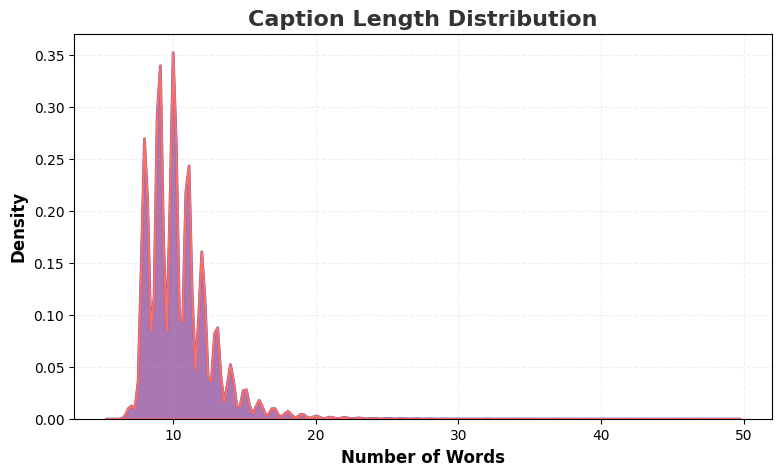

In [65]:
# PLOT OF THE CAPTION LENGTH DISTRIBUTION

plt.figure(figsize=(9,5))

sns.kdeplot(df['cap_len'], fill=True, color="#6A5ACD", alpha=0.8, linewidth=2)

sns.kdeplot(df['cap_len'], fill=True, color="#FF6F61", alpha=0.3, linewidth=1.5)



plt.title("Caption Length Distribution", fontsize=16, weight="bold", color="#333333")
plt.xlabel("Number of Words", fontsize=12, weight="bold")
plt.ylabel("Density", fontsize=12, weight="bold")
plt.grid(alpha=0.2, linestyle="--")
plt.show()

In [66]:
# removing outlier captions 

CSV_PATH = "/kaggle/working/captions.csv"
df = pd.read_csv(CSV_PATH)


def count_words(s):
    return len(str(s).split())


df["cap_len"] = df["caption"].apply(count_words)


MAX_LEN = 20

df = df[df["cap_len"] <= MAX_LEN].reset_index(drop=True)

print(f" Remaining captions: {len(df)}")
print(df["cap_len"].describe())


 Remaining captions: 93401
count    93401.000000
mean        10.374332
std          2.085812
min          6.000000
25%          9.000000
50%         10.000000
75%         11.000000
max         20.000000
Name: cap_len, dtype: float64


In [67]:
df.drop(columns=["cap_len"], inplace=True)
df.to_csv("/kaggle/working/captions_clean.csv", index=False)

# we save the final max 20 words captions to captions_clean


print(df.shape)

(93401, 2)


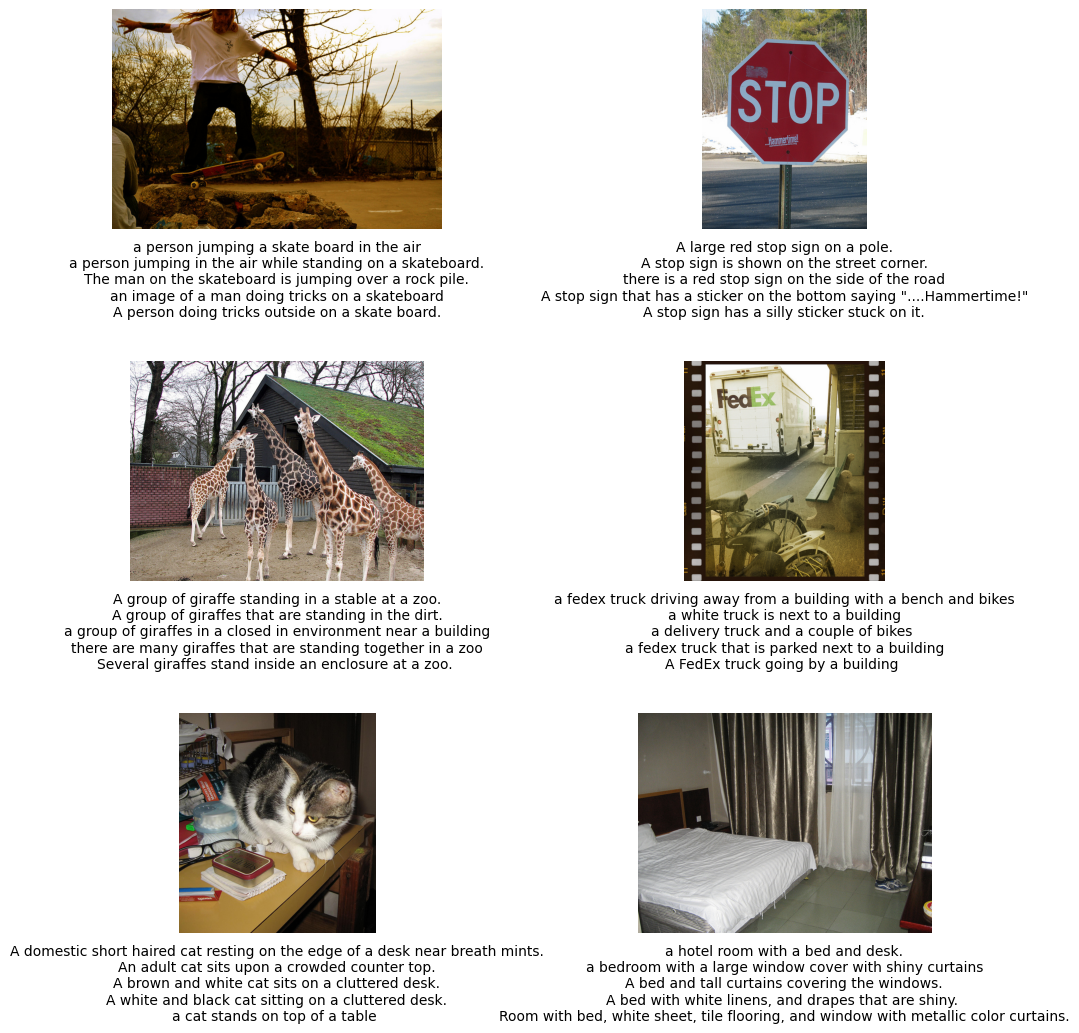

In [68]:

img_paths = random.sample(list(df["image_path"].unique()), 6)

plt.figure(figsize=(12, 12))

for i, img_path in enumerate(img_paths, 1):
    ax = plt.subplot(3, 2, i)          
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis('off')
    
    
    caps = df[df["image_path"] == img_path]["caption"].tolist()
    
    
    ax.text(
        0.5, -0.05, "\n".join(caps),
        ha='center', va='top', fontsize=10, wrap=True, transform=ax.transAxes
    )

plt.subplots_adjust(hspace=0.6)  
plt.show()

In [69]:
# lets tokenize and map the words to integers .. 


captions = df["caption"].tolist()

def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9 ]", "", text)  # keep letters/numbers only
    return text.split()


word_counts = {}

for caption in captions:
    for word in tokenize(caption):
        word_counts[word] = word_counts.get(word, 0) + 1


min_freq = 5

words = [w for w,f in word_counts.items() if f >= min_freq]


special_tokens = ["<pad>", "<start>", "<end>", "<unk>"]


vocab_words = special_tokens + words


word_to_index = {w:i for i,w in enumerate(vocab_words)}   # string -> index
index_to_word = {i:w for i,w in enumerate(vocab_words)}   # index -> string

print("Vocabulary size:", len(vocab_words))


Vocabulary size: 4505


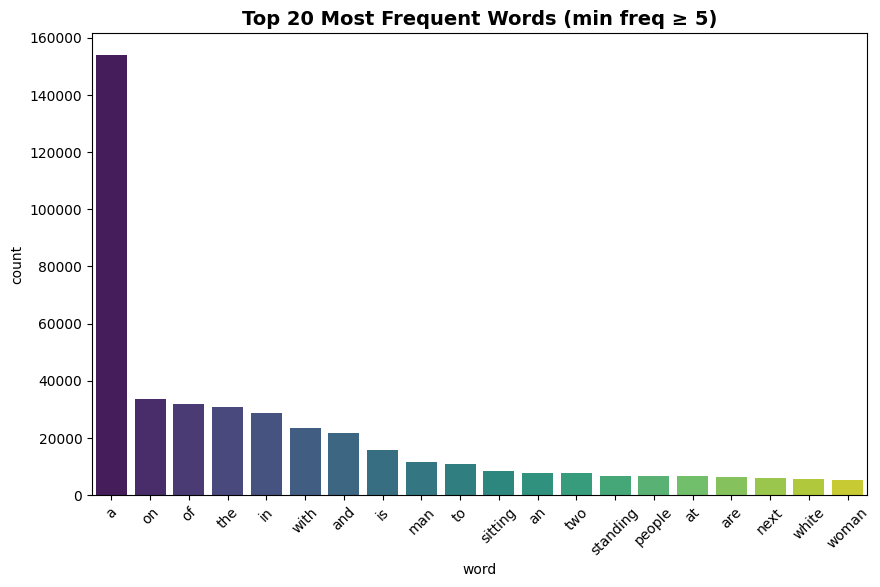

In [70]:
# THE MOST FREQUENT WORDS 


filtered_counts = {w: c for w, c in word_counts.items() if w in words}


# Get top 20 frequent words
top_words = pd.DataFrame(
    Counter(filtered_counts).most_common(20),
    columns=['word','count']
)



plt.figure(figsize=(10,6))
sns.barplot(x='word', y='count', data=top_words, palette="viridis")
plt.title("Top 20 Most Frequent Words (min freq ≥ 5)", fontsize=14, weight="bold")
plt.xticks(rotation=45)
plt.show()


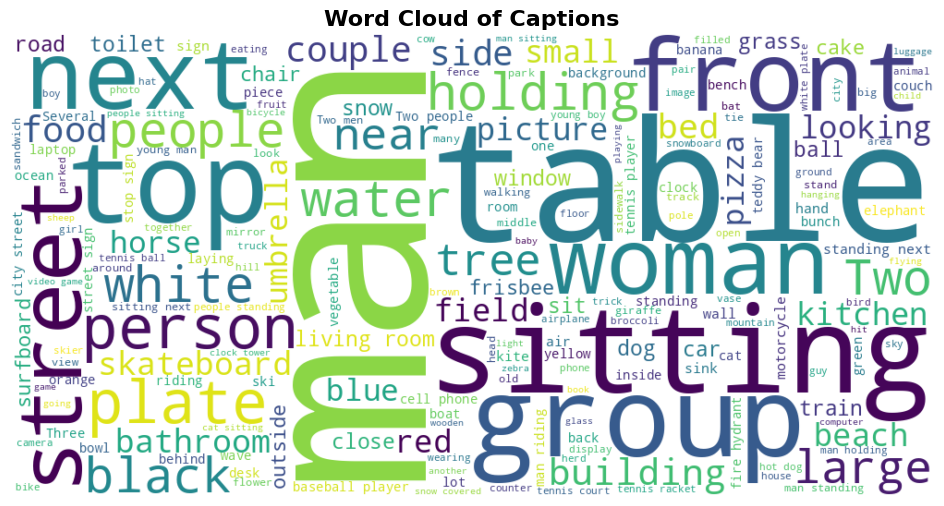

In [71]:
# PLOT THE WORDS WHICH DOMINATE 

from wordcloud import WordCloud


all_text = " ".join(df["caption"].tolist())


wc = WordCloud(
    width=1000, height=500,
    background_color="white",
    max_words=200,          # show top 200 words
    colormap="viridis"      # nice color map
).generate(all_text)



plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Captions", fontsize=16, weight="bold")
plt.show()


In [72]:
# MAX_LEN = 20 

def encode_caption(caption, max_len=MAX_LEN):

    words = tokenize(caption)[:max_len-2]         # trim to fit max_len
    
    tokens = [word_to_index["<start>"]]           # start token
    
    tokens = tokens + [word_to_index.get(w, word_to_index["<unk>"]) for w in words]  # words
    
    tokens.append(word_to_index["<end>"])         # end token

    
    # Pad if needed
    while len(tokens) < max_len:
        tokens.append(word_to_index["<pad>"])
    
    return tokens



example_indices = [0, 15, 42, 128, 256]  # pick 3-5 examples from your dataset

for idx in example_indices:
    print("Original caption:", captions[idx])
    print("")
    print("Encoded:", encode_caption(captions[idx]))
    print("\n" + "-"*60 + "\n")  # separator for neatness



Original caption: A white square kitchen with tile floor that needs repairs 

Encoded: [1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 2, 0, 0, 0, 0, 0, 0, 0, 0]

------------------------------------------------------------

Original caption: A person, protected from the rain by their umbrella, walks down the road.

Encoded: [1, 4, 37, 74, 75, 16, 76, 51, 77, 78, 79, 80, 16, 81, 2, 0, 0, 0, 0, 0]

------------------------------------------------------------

Original caption: White bathroom with glass shelves and wood sink.

Encoded: [1, 5, 96, 8, 163, 164, 25, 165, 24, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

------------------------------------------------------------

Original caption: A silver sedan is parked in a plaza lot on a cloudy day.

Encoded: [1, 4, 233, 3, 128, 334, 14, 4, 339, 338, 18, 4, 341, 92, 2, 0, 0, 0, 0, 0]

------------------------------------------------------------

Original caption: Three lighted doors have gold rectangular lights above them.

Encoded: [1, 537, 235, 22, 540, 5

In [73]:
# to encode each caption in my df 

encoded_captions = [encode_caption(cap) for cap in df['caption'].tolist()]

captions_np = np.array(encoded_captions)

----------------------------------------------------------------------------------------------------------------

# **EFFICIENT NET B3 ENCODER** :

In [82]:
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Reshape, Resizing
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Parameters
img_size = 300
spatial_size = 10
embed_size = 256

# Backbone
base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
base_model.trainable = False

# Encoder
inputs = Input(shape=(img_size, img_size, 3))

# EfficientNet features
x = base_model(inputs)   # [B, H_feat, W_feat, 1536]

# Resize feature map to fixed spatial size
x = Resizing(spatial_size, spatial_size)(x)   # [B, 10, 10, 1536]

# Flatten spatial grid
x = Reshape((spatial_size * spatial_size, 1536))(x)   # [B, 100, 1536]

# Project to embedding dimension
outputs = Dense(embed_size)(x)   # [B, 100, 256]

# Final encoder model
image_encoder = Model(inputs, outputs)

image_encoder.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_1 (Resizing)           │ (None, 10, 10, 1536)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 100, 1536)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100, 256)       │       393,472 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,177,007 (42.64 MB)

 Trainable params: 393,472 (1.50 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

In [25]:
# Image loading + preprocessing helper

def load_and_preprocess(img_path):
    img = Image.open(img_path).convert("RGB").resize((img_size, img_size))
    img = np.array(img)
    img = preprocess_input(img)        # <-- Correct EfficientNet preprocessing to [-1, 1]
    return img

In [26]:
import os
import numpy as np
from tqdm import tqdm
from PIL import Image

# Parameters

chunk_size = 2000

save_dir = "/kaggle/working/features"

os.makedirs(save_dir, exist_ok=True)


# Assuming df['image_path'] contains all image paths

unique_images = df['image_path'].drop_duplicates().tolist()

n_images = len(unique_images)

print(f"Total unique images: {n_images}")

n_chunks = (n_images + chunk_size - 1) // chunk_size

print(f"Number of chunks: {n_chunks}")


# Extract features chunk by chunk
for chunk_idx in range(n_chunks):
    
    start = chunk_idx * chunk_size
    
    end = min(start + chunk_size, n_images)
    
    batch_paths = unique_images[start:end]
    
    imgs = np.array([load_and_preprocess(p) for p in batch_paths])
    
    # Pass through encoder
    features = image_encoder.predict(imgs, batch_size=32, verbose=1)
    
    # Save chunk
    np.save(os.path.join(save_dir, f"image_features_chunk_{chunk_idx}.npy"), features)
    print(f" Saved chunk {chunk_idx}, images {start}-{end-1}, shape {features.shape}")

Total unique images: 18783
Number of chunks: 10


I0000 00:00:1757102873.579360     105 service.cc:148] XLA service 0x78e4d4002240 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757102873.580111     105 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1757102873.580132     105 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1757102874.664969     105 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/63 ━━━━━━━━━━━━━━━━━━━━ 16:19 16s/step

I0000 00:00:1757102883.828442     105 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


63/63 ━━━━━━━━━━━━━━━━━━━━ 35s 317ms/step
 Saved chunk 0, images 0-1999, shape (2000, 100, 256)
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step
 Saved chunk 1, images 2000-3999, shape (2000, 100, 256)
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step
 Saved chunk 2, images 4000-5999, shape (2000, 100, 256)
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step
 Saved chunk 3, images 6000-7999, shape (2000, 100, 256)
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step
 Saved chunk 4, images 8000-9999, shape (2000, 100, 256)
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step
 Saved chunk 5, images 10000-11999, shape (2000, 100, 256)
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 111ms/step
 Saved chunk 6, images 12000-13999, shape (2000, 100, 256)
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step
 Saved chunk 7, images 14000-15999, shape (2000, 100, 256)
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step
 Saved chunk 8, images 16000-17999, shape (2000, 100, 256)
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 425ms/step
 Saved chunk 9, images 18000-18782, shape (783, 100, 256)


In [21]:
# MERGING ALL CHUNKS  

save_dir = "/kaggle/working/features"

os.makedirs(save_dir, exist_ok=True)

all_features = []


for f in sorted(os.listdir(save_dir)):
    if f.startswith("image_features_chunk"):
        chunk = np.load(os.path.join(save_dir, f))
        all_features.append(chunk)


all_features = np.vstack(all_features)

print(f" All features merged: {all_features.shape}")

np.save(os.path.join(save_dir, "image_features_new.npy"), all_features)

 All features merged: (18783, 100, 256)


------------------------------------------------------------------------------------------------------------------------------------------------

# **LOADING AND SPLITTING OUR DATA**

In [74]:


all_features = np.load("/kaggle/input/features/image_features_new.npy")  # shape [n_images, 100, 256]

unique_images = df['image_path'].drop_duplicates().tolist()

img_to_idx = {path: idx for idx, path in enumerate(unique_images)}


# Captions already encoded
captions_np = np.array(encoded_captions)   # shape [n_captions, max_len]


# Inputs and targets
X_caps = captions_np[:, :-1]

Y_caps = captions_np[:, 1:]

Y_caps = np.expand_dims(Y_caps, -1)   # [B, T, 1]



In [75]:

# 1. Unique images split

unique_images = df['image_path'].unique()

train_imgs, temp_imgs = train_test_split(unique_images, test_size=0.2, random_state=42)

val_imgs, test_imgs   = train_test_split(temp_imgs, test_size=0.5, random_state=42)

# 2. Build split dataframes

train_df = df[df['image_path'].isin(train_imgs)]

val_df   = df[df['image_path'].isin(val_imgs)]

test_df  = df[df['image_path'].isin(test_imgs)]


# 3. Extract captions & targets

cap_train  = X_caps[train_df.index]
y_train    = Y_caps[train_df.index]
paths_train = train_df['image_path'].tolist()

cap_val    = X_caps[val_df.index]
y_val      = Y_caps[val_df.index]
paths_val   = val_df['image_path'].tolist()

cap_test   = X_caps[test_df.index]
y_test     = Y_caps[test_df.index]
paths_test  = test_df['image_path'].tolist()


print("Train captions:", cap_train.shape, "Val:", cap_val.shape, "Test:", cap_test.shape)

print("Train targets:", y_train.shape, "Val:", y_val.shape, "Test:", y_test.shape)

print("Unique Images → Train:", len(train_imgs), "Val:", len(val_imgs), "Test:", len(test_imgs))


# 4. Features lookup (map image_path -> index in all_features)

unique_images_ordered = df['image_path'].drop_duplicates().tolist()

img_to_idx = {path: idx for idx, path in enumerate(unique_images_ordered)}

# Example: get features for first training path
sample_feat = all_features[img_to_idx[paths_train[0]]]   # shape [100, 256]


Train captions: (74709, 19) Val: (9348, 19) Test: (9344, 19)
Train targets: (74709, 19, 1) Val: (9348, 19, 1) Test: (9344, 19, 1)
Unique Images → Train: 15026 Val: 1878 Test: 1879


In [76]:

class CaptionGenerator(Sequence):
    
    def __init__(self, captions, targets, paths, all_features, img_to_idx, batch_size=64, shuffle=True):
        
        self.captions = captions          # shape [n, max_len]
        self.targets = targets            # shape [n, max_len, 1]
        self.paths = paths                # list of image paths (len = n)
        self.all_features = all_features  # [n_images, 100, 256]
        self.img_to_idx = img_to_idx      # dict: path → index in all_features
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.captions))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.captions) / self.batch_size))

    def __getitem__(self, idx):
        
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
    
        batch_caps = self.captions[batch_idx]   # (B, max_len)
        batch_tgts = self.targets[batch_idx]    # (B, max_len, 1)
    
        # Get image features for each caption
        batch_feats = np.array([
            self.all_features[self.img_to_idx[self.paths[i]]]
            for i in batch_idx
        ])  # (B, 100, 256)
    
        #  Return as tuple, not list
        return (batch_feats, batch_caps), batch_tgts


    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)



# Train/val/test generators
train_gen = CaptionGenerator(cap_train, y_train, paths_train, all_features, img_to_idx, batch_size=64)

val_gen   = CaptionGenerator(cap_val,   y_val,   paths_val,   all_features, img_to_idx, batch_size=64)

test_gen  = CaptionGenerator(cap_test,  y_test,  paths_test,  all_features, img_to_idx, batch_size=64)



----------------------------------------------------------------------------------------------------------------

# **USING GLOVE EMBEDDINGS**

In [77]:
# using glove 200d embeddings 

glove_path = "/kaggle/input/glove-embedding/glove.6B.200d.txt"
glove_dict = {}


with open(glove_path, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.array(values[1:], dtype='float32')
        glove_dict[word] = vector


print("Loaded GloVe vectors:", len(glove_dict))


Loaded GloVe vectors: 400000


In [78]:
#creating the embedding matrix 


embed_size = 200    #(because glove is 200)

vocab_size = len(word_to_index)

embedding_matrix = np.zeros((vocab_size, embed_size))


for word, idx in word_to_index.items():
    if word in glove_dict:
        embedding_matrix[idx] = glove_dict[word]
    else:
        embedding_matrix[idx] = np.random.normal(scale=0.6, size=(embed_size,))


----------------------------------------------------------------------------------------------------------------

# **CUSTOM LOSS FUNCTION**

In [79]:
def masked_loss(y_true, y_pred):
    """
    Sparse caption loss with label smoothing and padding mask.
    """
    vocab_size = tf.shape(y_pred)[-1]

    # Remove last dim if needed
    y_true = tf.cast(tf.squeeze(y_true, axis=-1), tf.int32)  # Shape: [B, T]

    # One-hot encode targets
    y_true_one_hot = tf.one_hot(y_true, depth=vocab_size)

    # Label smoothing
    epsilon = 0.1
    y_true_smooth = (1 - epsilon) * y_true_one_hot + epsilon / tf.cast(vocab_size, tf.float32)

    # Categorical cross-entropy
    ce = tf.keras.losses.categorical_crossentropy(y_true_smooth, y_pred, from_logits=False)

    # Mask padding tokens (PAD=0)
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    ce = ce * mask

    return tf.reduce_sum(ce) / (tf.reduce_sum(mask) + 1e-9)

----------------------------------------------------------------------------------------------------------------

# **DECODER :**

In [83]:
from tensorflow.keras.layers import  LSTM, Multiply, Embedding, MultiHeadAttention, GlobalAveragePooling1D , LayerNormalization ,Dropout,Add


# Parameters

vocab_size = len(word_to_index)
embed_size = 200
lstm_units = 512

# Inputs

img_feat_in = Input(shape=(100, 256), name='img_features')  # Pre-extracted CNN features
cap_in = Input(shape=(MAX_LEN-1,), dtype='int32', name='captions')  # Tokenized captions

# Caption Embedding

cap_emb = Embedding(
    input_dim=vocab_size,
    output_dim=embed_size,
    weights=[embedding_matrix],
    trainable=False,
    mask_zero=True
)(cap_in)


# Initialize LSTM state from image features

global_img = GlobalAveragePooling1D()(img_feat_in)  # Shape: [batch, 256]
h_init = Dense(lstm_units, activation="tanh")(global_img)
c_init = Dense(lstm_units, activation="tanh")(global_img)

# LSTM

lstm_out = LSTM(
    lstm_units,
    return_sequences=True,
    dropout=0.3,
    recurrent_dropout=0.2
)(cap_emb, initial_state=[h_init, c_init])

# Project image features for attention

img_proj = Dense(lstm_units)(img_feat_in)

# Multi-Head Attention

attn_out = MultiHeadAttention(num_heads=8, key_dim=64)( query=lstm_out , value=img_proj , key=img_proj )

# Gated fusion of attention + LSTM output

gate = Dense(lstm_units, activation='sigmoid')(lstm_out)
context = Multiply()([attn_out, gate])

# Residual connection + Layer Normalization

combined = Add()([lstm_out, context])
combined = LayerNormalization()(combined)

# Feed-forward network

hidden = Dense(256, activation='relu')(combined)
hidden = Dropout(0.4)(hidden)
hidden = Dense(256, activation='relu')(hidden)

# Output layer

out = Dense(vocab_size, activation='softmax')(hidden)

# Define model

decoder_model = Model(inputs=[img_feat_in, cap_in], outputs=out)
    

decoder_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=masked_loss
)

decoder_model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img_features        │ (None, 100, 256)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ captions            │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ img_features[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 19, 200)   │    901,000 │ captions[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │    131,584 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 512)       │    131,584 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 19, 512)   │  1,460,224 │ embedding[0][0],  │
│                     │                   │            │ dense_2[0][0],    │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 100, 512)  │    131,584 │ img_features[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 19)        │          0 │ captions[0][0]    │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 19, 512)   │  1,050,624 │ dense_4[0][0],    │
│ (MultiHeadAttentio… │                   │            │ lstm[0][0],       │
│                     │                   │            │ not_equal[0][0],  │
│                     │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 19, 512)   │    262,656 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 19, 512)   │          0 │ multi_head_atten… │
│                     │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 19, 512)   │          0 │ lstm[0][0],       │
│                     │                   │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 19, 512)   │      1,024 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 19, 256)   │    131,328 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 19, 256)   │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 19, 256)   │     65,792 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 19, 4505)  │  1,157,785 │ dense_7[0][0]     │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 5,425,185 (20.70 MB)

 Trainable params: 4,524,185 (17.26 MB)

 Non-trainable params: 901,000 (3.44 MB)

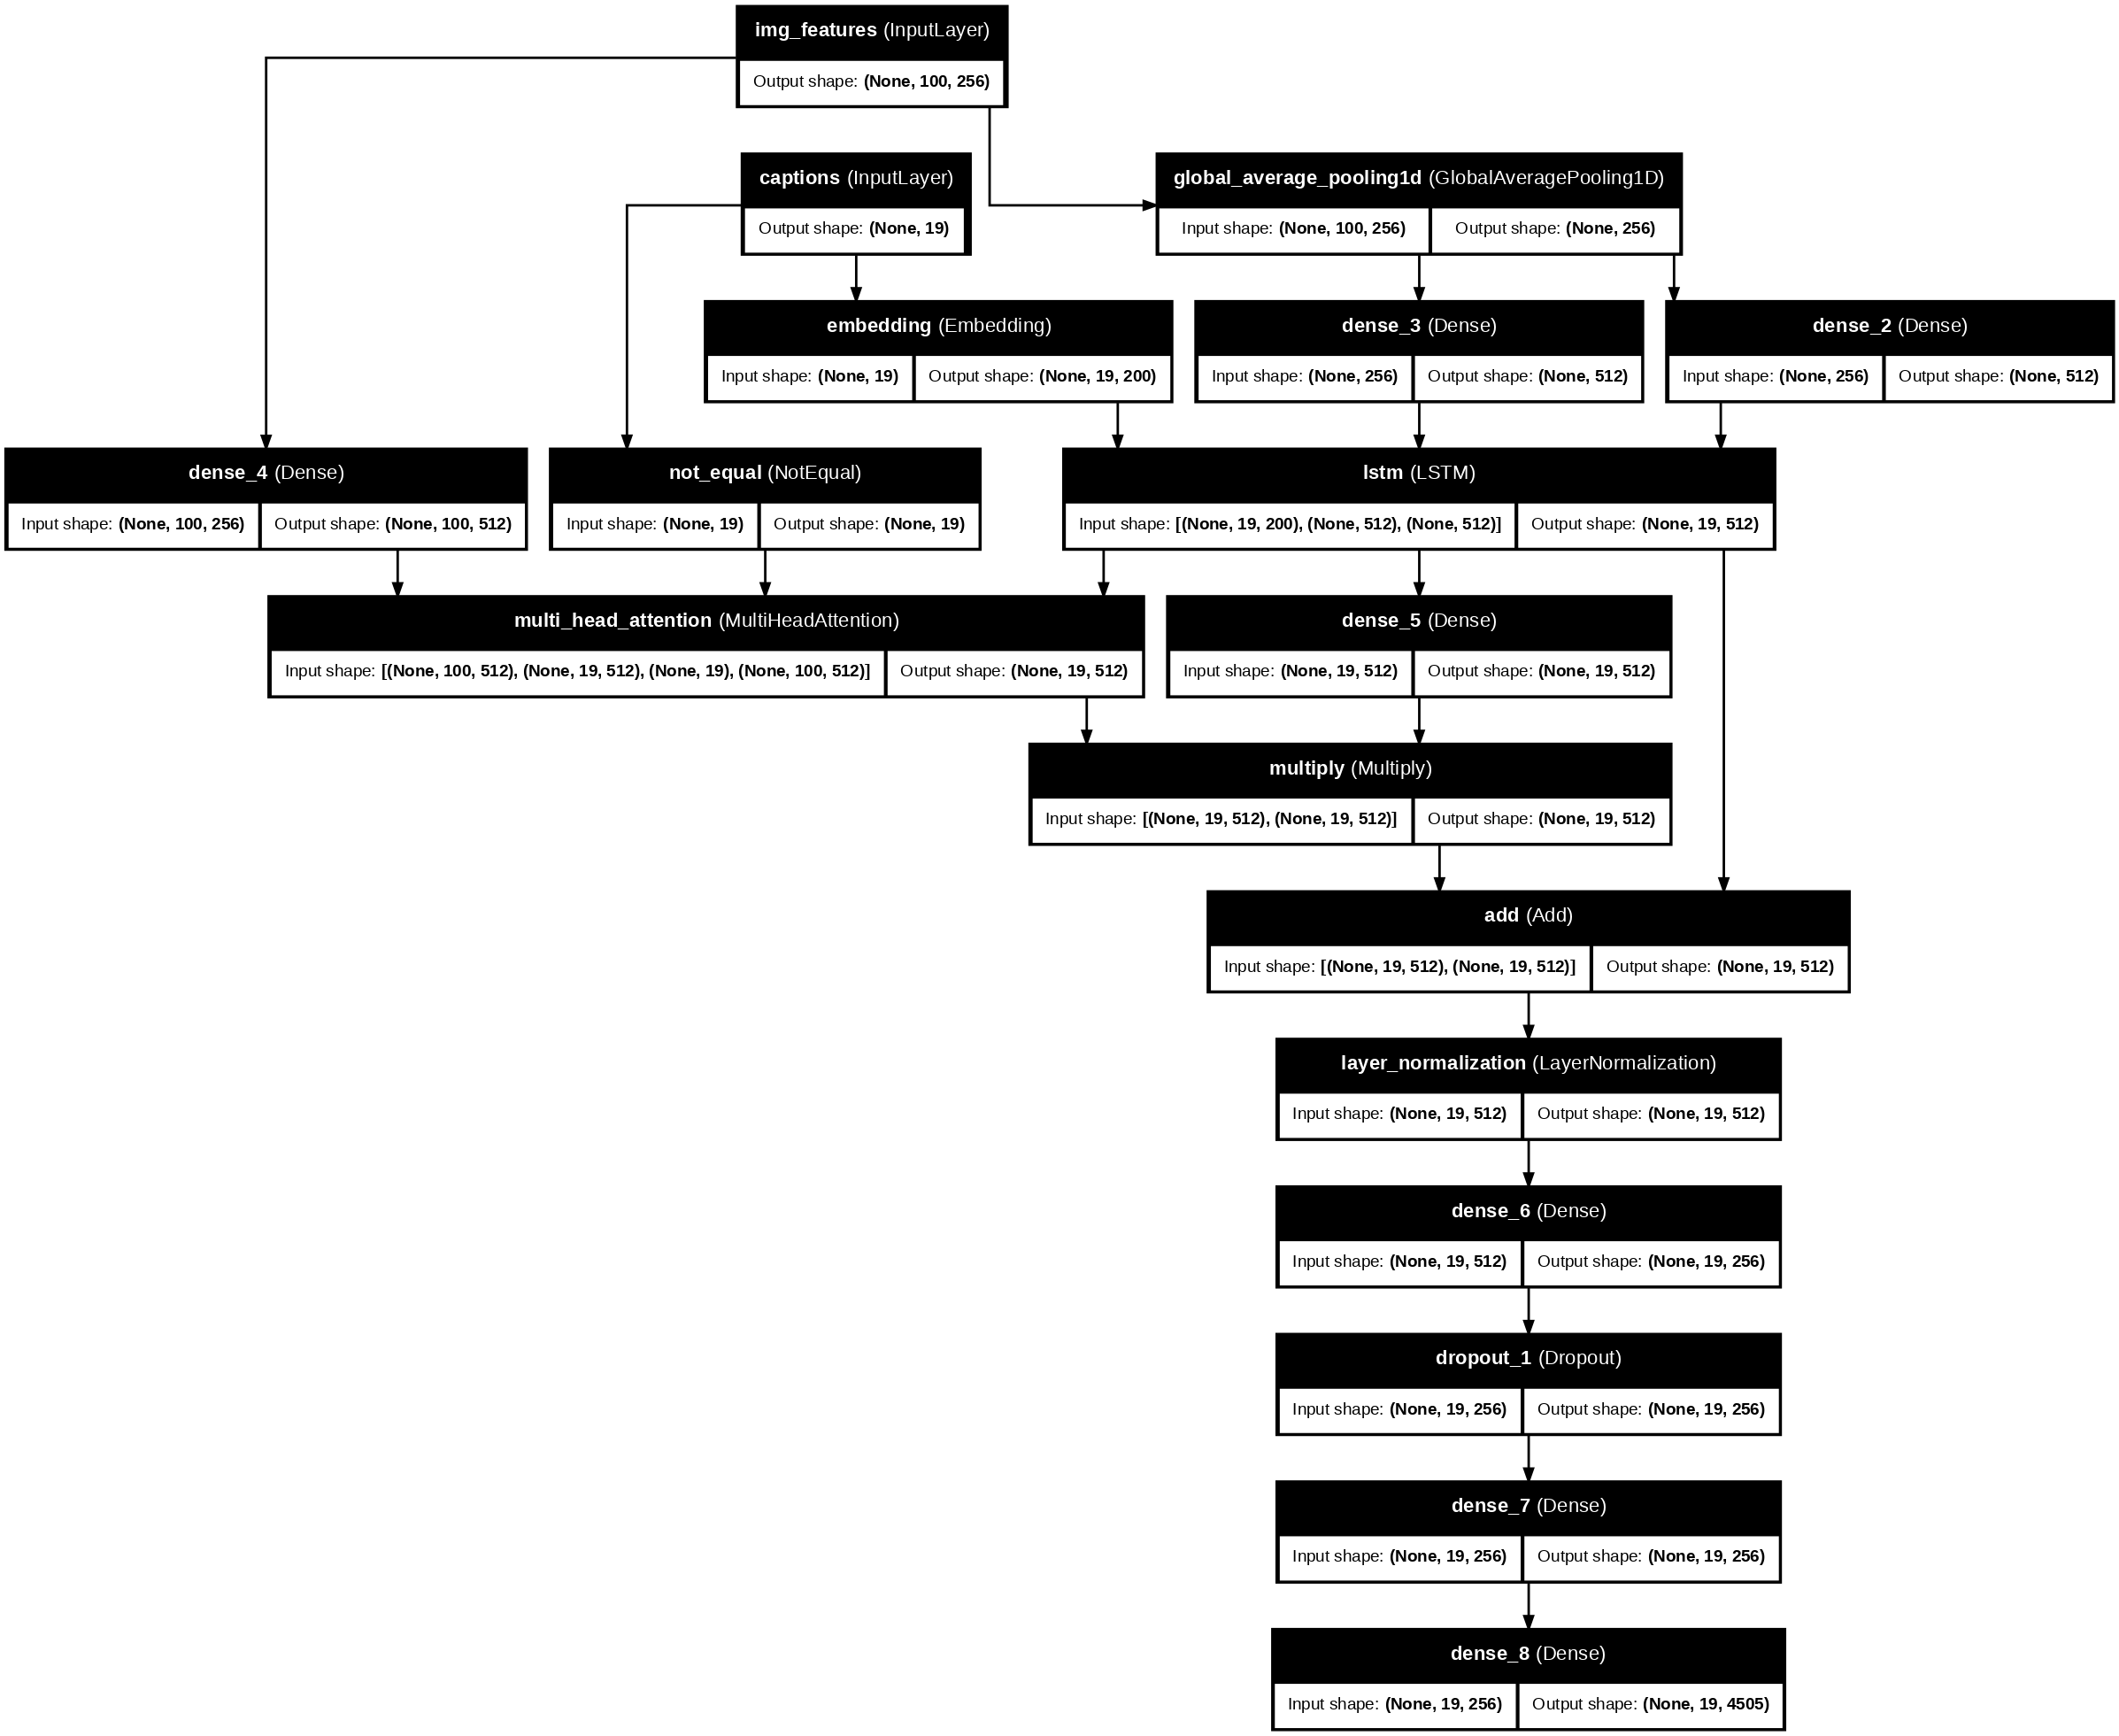

In [84]:
from tensorflow.keras.utils import plot_model

plot_model(decoder_model, 
           to_file="decoder_model.png", 
           show_shapes=True,     
           show_layer_names=True, 
           expand_nested=True,   
           dpi=100)


In [36]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,                 # stop earlier to prevent overfit
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,               # shrink LR faster if stuck
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath="best_decoder_additive.h5",
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,  # full model (weights+arch)
        verbose=1
    )
]


history = decoder_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=55,             
    callbacks=callbacks,
    verbose=1
)


Epoch 1/55


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1168/1168 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 5.6667
Epoch 1: val_loss improved from inf to 4.33685, saving model to best_decoder_additive.h5
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 98s 74ms/step - loss: 5.6661 - val_loss: 4.3369 - learning_rate: 1.0000e-04
Epoch 2/55
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 4.3730
Epoch 2: val_loss improved from 4.33685 to 4.04758, saving model to best_decoder_additive.h5
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 85s 73ms/step - loss: 4.3729 - val_loss: 4.0476 - learning_rate: 1.0000e-04
Epoch 3/55
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 4.1260
Epoch 3: val_loss improved from 4.04758 to 3.91356, saving model to best_decoder_additive.h5
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 85s 73ms/step - loss: 4.1259 - val_loss: 3.9136 - learning_rate: 1.0000e-04
Epoch 4/55
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 3.9942
Epoch 4: val_loss improved from 3.91356 to 3.83441, saving model to best_decoder_additive.h5
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 85s 73ms/st

----------------------------------------------------------------------------------------------------------------------------------------------------

# **SAVING OUR MODEL**

In [39]:
# Saving our model 

decoder_model.save("decoder_model_additive.keras")

print("Model saved as 'decoder_model_additive.keras'")

# (why not .h5 but keras , beacuse in my masked_loss i have a layer called NOT_EQUAL which is not preedefined in keras, so it shows error always )

Model saved as 'decoder_model_additive.keras'


In [94]:
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import custom_object_scope


with custom_object_scope({'masked_loss': masked_loss}):
    decoder_model = load_model("/kaggle/input/my-model/decoder_model_new.keras")

print("Model Loaded Succesfully")

Model Loaded Succesfully


----------------------------------------------------------------------------------------------------------------

# **GENERATING SOME CAPTIONS ON TEST IMAGES**

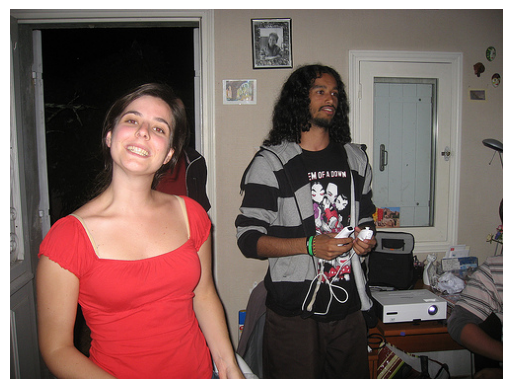

Original Captions:
1. a person posing for a photo with a person playing nintendo wii 
2. A woman smiling standing near a man holding a remote.
3. Several friends are in a room together while one is holding interactive video game controllers.
4. A smiling woman and a young man in a T shirt stand around in a bedroom.
5. A man and woman standing in a living room with video game controls.

Generated Caption:
<start> a woman holding a wii controller in his hand




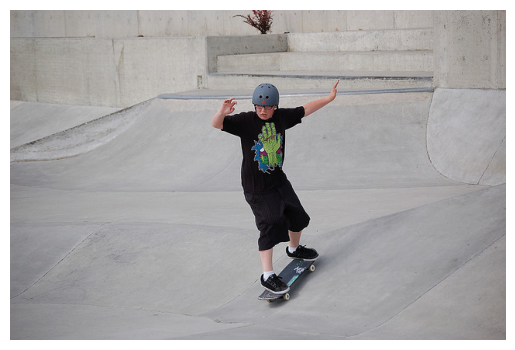

Original Captions:
1. A boy is on a cement bowl on a skateboard.
2. A young boy riding a skateboard on a cement park.
3. a little boy wearing a helmet while riding his skate board 
4. A boy wearing a helmet is riding a skateboard.
5. There is a boy riding on a skateboard in a skate park

Generated Caption:
<start> a man riding a skateboard down a ramp




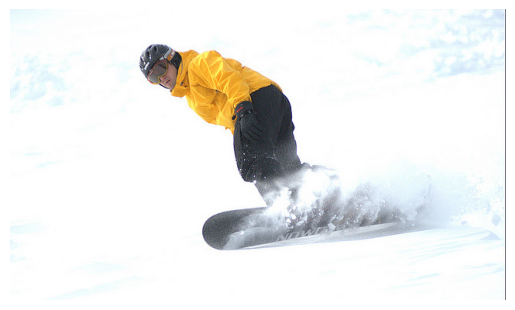

Original Captions:
1. A person riding a snowboard on a mountain slope.
2. A snowboarder leans as he skis down a hill.
3. A snowboarder swerving to the side of a hill.
4. A PERSON IN YELLOW AND BLACK IS SNOWBOARDER HEADING DOWN THE HILL
5. A man wearing a yellow jacket and sunglasses snowboarding down a hill

Generated Caption:
<start> a man riding a snowboard down a snow covered slope




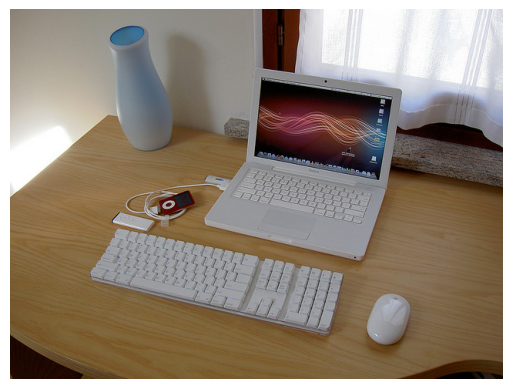

Original Captions:
1. An open laptop computer sitting on top of a wooden desk.
2. A LAP TOP IS ON THE DESK 
3. Desk area with laptop computer, external keyboard and iPod
4. This is a laptop on a desk beside a vase  along with an extra keyboard, mouse, and also an IPOD. 
5. A wood desk with a laptop computer, wireless keyboard and mouse and vase.

Generated Caption:
<start> a laptop computer sitting on top of a desk




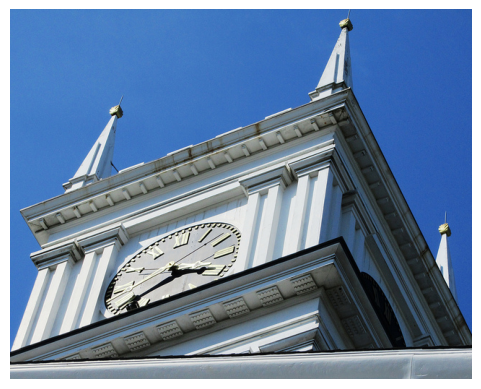

Original Captions:
1. A clock on top of a church steeple with a blue sky in the background.
2. A clock on a steeple of a tall building.
3. Large Clock in building tower showing 4:40 pm.
4. A circular clock housed in an ornate white tower.
5. Under a blue sky stands a tower with a large clock on it.

Generated Caption:
<start> a clock tower with a clock on it




In [96]:
# Helper: Convert token ids to caption string

def tokens_to_caption(tokens):
    
    words = []
    
    for t in tokens:
        if t == 0:  # PAD
            continue
        
        word = index_to_word.get(t, '')
        
        if word == '<end>':
            break
        words.append(word)
    return ' '.join(words)





def beam_search_decoder(img_feat, beam_width=3, max_len=20):
   
    start_seq = [word_to_index["<start>"]]
    
    sequences = [(start_seq, 0.0)]  

    for _ in range(max_len):
        
        all_candidates = []
        
        for seq, score in sequences:
            if seq[-1] == word_to_index["<end>"]:
                all_candidates.append((seq, score))
                continue

            img_input = np.expand_dims(img_feat, axis=0)
            cap_input = pad_sequences([seq], maxlen=max_len-1, padding='post')

            preds = decoder_model.predict([img_input, cap_input], verbose=0)    # [1, T, vocab_size]

            step = len(seq) - 1
            if step >= preds.shape[1]:
                continue  

            preds = preds[0, step]  
            top_indices = np.argsort(preds)[-beam_width:][::-1]

            for idx in top_indices:
                candidate = (seq + [idx], score - np.log(preds[idx] + 1e-9))
                all_candidates.append(candidate)

        sequences = sorted(all_candidates, key=lambda tup: tup[1])[:beam_width]

    return sequences[0][0]

    





def show_image_and_captions(idx, beam_width=5):
    
    img_path = paths_val[idx]
    img_feat = all_features[img_to_idx[img_path]]
    
    
    # Show image
    img = Image.open(img_path).convert("RGB")
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    
   
    # Original captions
    orig = df[df['image_path'] == img_path]['caption'].tolist()
    print("Original Captions:")
    for i, c in enumerate(orig):
        print(f"{i+1}. {c}")
    
    
    # Generated caption
    gen_tokens = beam_search_decoder(img_feat, beam_width=beam_width)
    gen_caption = tokens_to_caption(gen_tokens)
    print("\nGenerated Caption:")
    print(gen_caption)
    print("\n" + "="*80 + "\n")




num_samples = 5
sample_indices = random.sample(range(len(paths_test)), num_samples)

for idx in sample_indices:
    show_image_and_captions(idx, beam_width=5)

----------------------------------------------------------------------------------------------------------------

# **EVALUATING BLEU SCORES**


**BLEU (Bilingual Evaluation Understudy)** is a widely used metric to evaluate the quality of generated text by comparing it to one or more reference texts. It measures **n-gram overlap**, giving higher scores when the generated caption closely matches the reference captions.

- **BLEU-1:** Measures overlap of **unigrams** (single words) between the generated caption and reference captions.  
- **BLEU-2:** Measures overlap of **bigrams** (2-word sequences).  
- **BLEU-3:** Measures overlap of **trigrams** (3-word sequences).  
- **BLEU-4:** Measures overlap of **4-grams** (4-word sequences).


In [38]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction


beam_width = 5
smooth_fn = SmoothingFunction().method1  


def tokens_to_words(tokens):
    return [index_to_word[t] for t in tokens if t != word_to_index["<pad>"]]

subset_size = 1500
subset_paths = random.sample(paths_test, subset_size)

bleu1_list, bleu2_list, bleu3_list, bleu4_list = [], [], [], []


for idx in tqdm(range(len(subset_paths)), desc="Calculating BLEU (1500 subset)"):
    img_feat = all_features[img_to_idx[subset_paths[idx]]]


    references = []
    img_captions = df[df['image_path'] == subset_paths[idx]]['caption'].tolist()
    for cap in img_captions:
        tokens = encode_caption(cap, max_len=MAX_LEN)
        references.append(tokens_to_words(tokens))


    gen_tokens = beam_search_decoder(img_feat, beam_width=beam_width, max_len=MAX_LEN)
    gen_caption = tokens_to_words(gen_tokens)


    bleu1_list.append(sentence_bleu(references, gen_caption, weights=(1,0,0,0), smoothing_function=smooth_fn))
    bleu2_list.append(sentence_bleu(references, gen_caption, weights=(0.5,0.5,0,0), smoothing_function=smooth_fn))
    bleu3_list.append(sentence_bleu(references, gen_caption, weights=(0.33,0.33,0.33,0), smoothing_function=smooth_fn))
    bleu4_list.append(sentence_bleu(references, gen_caption, weights=(0.25,0.25,0.25,0.25), smoothing_function=smooth_fn))


print(f"Evaluated on {subset_size} random test images")
print(f"BLEU-1: {np.mean(bleu1_list):.4f}")
print(f"BLEU-2: {np.mean(bleu2_list):.4f}")
print(f"BLEU-3: {np.mean(bleu3_list):.4f}")
print(f"BLEU-4: {np.mean(bleu4_list):.4f}")


Calculating BLEU (1500 subset): 100%|██████████| 1500/1500 [2:08:45<00:00,  5.15s/it] 

Evaluated on 1500 random test images
BLEU-1: 0.7135
BLEU-2: 0.5343
BLEU-3: 0.3731
BLEU-4: 0.2606


----------------------------------------------------------------------------------------

 # **EVALUATING METEOR**


 **METEOR (Metric for Evaluation of Translation with Explicit ORdering)** evaluates generated text by comparing it to reference texts using **precision, recall, and alignment of unigrams**, while also considering **stemmed words and synonyms** for better linguistic matching.

- **Unigram matching:** Compares individual words between generated and reference captions.  
- **Stemming & Synonyms:** Counts matches for words with the same root or meaning.  
- **Precision & Recall:** Balances how much of the generated caption is correct (precision) and how much of the reference is covered (recall).  
- **Final Score:** Combines these factors into a single score between 0 (worst) and 1 (best).


In [32]:
from nltk.translate.meteor_score import meteor_score


def evaluate_meteor(paths, beam_width=5, subset_size=1500):

    subset_paths = random.sample(paths, subset_size)
    scores = []
    
    for img_path in tqdm(subset_paths, desc="Calculating METEOR (1500 subset)"):

        img_feat = all_features[img_to_idx[img_path]]


        gen_tokens = beam_search_decoder(img_feat, beam_width=beam_width)
        gen_caption = tokens_to_caption(gen_tokens)


        references = df[df['image_path'] == img_path]['caption'].tolist()


        score = meteor_score([ref.split() for ref in references], gen_caption.split())
        scores.append(score)

    return np.mean(scores)




meteor_avg = evaluate_meteor(paths_test, beam_width=5, subset_size=1500)


print(f"Evaluated on 1500 random test images")
print(f"Average METEOR score: {meteor_avg:.4f}")


Calculating METEOR (1500 subset): 100%|██████████| 1500/1500 [2:03:48<00:00,  4.95s/it] 

Evaluated on 1500 random test images
Average METEOR score: 0.4042


----------------------------------------------------------------------------------------------------------------

# **CONCLUSION**

## The image captioning model was evaluated using **BLEU** and **METEOR** metrics.  

- **BLEU-1 :**  0.7135
 <br>
- **BLEU-2 :**  0.5343  
- **BLEU-3 :**  0.3731  
- **BLEU-4 :**  0.2606  
- **METEOR :**  0.4042  

These results indicate that the model captures **key visual concepts** reasonably well and generates captions that are often **grammatically correct and meaningful**.  

---